# Data Exploration Notebook

## Purpose

We want to understand the raw shape of each data source, as we will look into what fields are available, how FIPS codes are represented, what date formats look like, and what data-quality issues we'll need to handle during cleaning. In this notebook, we aim to fetch small samples from all three sources:
— FEMA, Census, and HUD

As we will document what we discovered, the challenges we identified, and the design decisions those discoveries informed.


## 1. FEMA Disaster Declarations (API Exploration)

In [1]:
import requests
import pandas as pd
import json
from pprint import pprint

print("="*60)
print("FEMA API DATA EXPLORATION")
print("="*60)

# Fetch just 10 records to examine structure
fema_url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries"
params = {"$top": 10}

try:
    response = requests.get(fema_url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    print("\nAPI Response Structure:")
    print("Top-level keys:", list(data.keys()))

    if 'DisasterDeclarationsSummaries' in data:
        records = data['DisasterDeclarationsSummaries']
        print(f"\nNumber of records fetched: {len(records)}")

        # Examine the first record in detail
        print("\n" + "="*60)
        print("FIRST RECORD STRUCTURE (detailed view):")
        print("="*60)
        pprint(records[0], depth=2)


        # Convert to DataFrame to see structure
        df = pd.DataFrame(records)

        print("\n" + "="*60)
        print("DATAFRAME OVERVIEW:")
        print("="*60)
        print(f"Shape: {df.shape}")
        print(f"\nColumns ({len(df.columns)}):")
        for col in df.columns:
            print(f"  - {col}")

        print("\n" + "="*60)
        print("DATA TYPES:")
        print("="*60)
        print(df.dtypes)

        print("\n" + "="*60)
        print("SAMPLE DATA (first 3 rows):")
        print("="*60)
        print(df.head(3))

        print("\n" + "="*60)
        print("MISSING VALUES:")
        print("="*60)
        missing = df.isnull().sum()
        print(missing[missing > 0])

        print("\n" + "="*60)
        print("KEY FIELDS FOR SCHEMA DESIGN:")
        print("="*60)
        print("\nFIPS-related fields:")
        fips_cols = [col for col in df.columns if 'fips' in col.lower()]
        print(fips_cols)
        if fips_cols:
            for col in fips_cols:
                print(f"\n{col}:")
                print(f"  Type: {df[col].dtype}")
                print(f"  Sample values: {df[col].head(3).tolist()}")
                print(f"  Null count: {df[col].isnull().sum()}")

        print("\nDate-related fields:")
        date_cols = [col for col in df.columns if 'date' in col.lower()]
        print(date_cols)
        if date_cols:
            for col in date_cols:
                print(f"\n{col}:")
                print(f"  Type: {df[col].dtype}")
                print(f"  Sample values: {df[col].head(3).tolist()}")

        print("\nIncident/Disaster type fields:")
        incident_cols = [col for col in df.columns if any(word in col.lower() for word in ['incident', 'disaster', 'type'])]
        print(incident_cols)
        if incident_cols:
            for col in incident_cols:
                print(f"\n{col}:")
                print(f"  Type: {df[col].dtype}")
                print(f"  Unique values: {df[col].nunique()}")
                print(f"  Sample values: {df[col].unique()[:5].tolist()}")

        # Save sample for reference
        df.to_csv('fema_sample_data.csv', index=False)
        print("\n" + "="*60)
        print("Sample data saved to: fema_sample_data.csv")
        print("="*60)

except Exception as e:
    print(f"Error: {e}")

FEMA API DATA EXPLORATION

API Response Structure:
Top-level keys: ['metadata', 'DisasterDeclarationsSummaries']

Number of records fetched: 10

FIRST RECORD STRUCTURE (detailed view):
{'declarationDate': '2024-08-09T00:00:00.000Z',
 'declarationRequestNumber': '24122',
 'declarationTitle': 'LEE FALLS FIRE',
 'declarationType': 'FM',
 'designatedArea': 'Washington (County)',
 'designatedIncidentTypes': 'R',
 'disasterCloseoutDate': None,
 'disasterNumber': 5529,
 'femaDeclarationString': 'FM-5529-OR',
 'fipsCountyCode': '067',
 'fipsStateCode': '41',
 'fyDeclared': 2024,
 'hash': 'ae87cf3c6ed795015b714af7166c7c295b2b67c7',
 'hmProgramDeclared': True,
 'iaProgramDeclared': False,
 'id': '09e3f81a-5e16-4b72-b317-1c64e0cfa59c',
 'ihProgramDeclared': False,
 'incidentBeginDate': '2024-08-08T00:00:00.000Z',
 'incidentEndDate': None,
 'incidentId': '2024081001',
 'incidentType': 'Fire',
 'lastIAFilingDate': None,
 'lastRefresh': '2024-08-27T18:22:14.800Z',
 'paProgramDeclared': True,
 'place

FIPS is split ('41' + '067') Need to concatenate

Date format has ISO suffix → Need to strip it
- declarationDate = '2024-08-09T00:00:00.000Z' → Need to extract '2024-08-09'


Shape (10, 28): 10 rows (sample), 28 columns

That's alot of column, however, mainly because of metadata that we would not need for analysis, we dropping later: hash, lastRefresh, femaDeclarationString (internal metadata)

Keep: fipsStateCode, fipsCountyCode, disasterNumber, declarationDate, program flags, etc

looking at the sample data:
so '41' is OR and '067' is Washington county

we need to convert declarationDate = '2024-08-09T00:00:00.000Z' to proper date format '2024-08-09'

no missin value for FIPS



## 2. Census ACS 5-Year Estimates (API Exploration)

In [2]:
print("\n" + "="*80)
print("PART 2: CENSUS ACS 5-YEAR ESTIMATES API EXPLORATION")
print("="*80)

# Census API requires a key, but you can get one for free at:
# https://api.census.gov/data/key_signup.html
# For exploration, we'll use the public endpoint which has rate limits

census_base_url = "https://api.census.gov/data/2022/acs/acs5"

# Key demographic variables to explore:
# B01001_001E - Total Population
# B19013_001E - Median Household Income
# B17001_002E - Income below poverty level
# B23025_005E - Unemployment

variables = {
    'B01001_001E': 'total_population',
    'B19013_001E': 'median_household_income',
    'B17001_002E': 'poverty_count',
    'B23025_005E': 'unemployment_count',
    'B23025_003E': 'labor_force_count'
}

# Request format: get=NAME,B01001_001E&for=county:*&in=state:*
params = {
    'get': 'NAME,' + ','.join(variables.keys()),
    'for': 'county:*',
    'in': 'state:*'
}

try:
    print("\nFetching Census ACS data...")
    print("Note: This may take 30-60 seconds due to the large dataset")

    response = requests.get(census_base_url, params=params, timeout=60)
    response.raise_for_status()

    data = response.json()

    # First row is headers
    headers = data[0]
    records = data[1:]

    print(f"\nFetched {len(records)} county records")
    print(f"Columns: {headers}")

    # Convert to DataFrame
    df_census = pd.DataFrame(records, columns=headers)

    print("\n" + "-"*80)
    print("CENSUS DATA STRUCTURE:")
    print("-"*80)
    print(df_census.head(10))

    print("\n" + "-"*80)
    print("DATA TYPES (before conversion):")
    print("-"*80)
    print(df_census.dtypes)

    # Convert numeric columns
    for var_code in variables.keys():
        if var_code in df_census.columns:
            df_census[var_code] = pd.to_numeric(df_census[var_code], errors='coerce')

    print("\n" + "-"*80)
    print("FIPS CODE CONSTRUCTION:")
    print("-"*80)
    df_census['state_fips'] = df_census['state'].str.zfill(2)
    df_census['county_fips'] = df_census['county'].str.zfill(3)
    df_census['fips'] = df_census['state_fips'] + df_census['county_fips']

    print(df_census[['NAME', 'state', 'county', 'state_fips', 'county_fips', 'fips']].head(10))

    print(f"\nTotal unique FIPS codes: {df_census['fips'].nunique()}")

    print("\n" + "-"*80)
    print("VARIABLE ANALYSIS:")
    print("-"*80)

    for var_code, var_name in variables.items():
        if var_code in df_census.columns:
            print(f"\n{var_name} ({var_code}):")
            print(f"  Data type: {df_census[var_code].dtype}")
            print(f"  Null/Missing values: {df_census[var_code].isnull().sum()}")
            print(f"  Min: {df_census[var_code].min()}")
            print(f"  Max: {df_census[var_code].max()}")
            print(f"  Mean: {df_census[var_code].mean():.2f}")

            # Check for special values (Census uses -666666666 for missing)
            negative_count = (df_census[var_code] < 0).sum()
            if negative_count > 0:
                print(f"  WARNING: {negative_count} negative values detected (may indicate missing/suppressed data)")

    print("\n" + "-"*80)
    print("DERIVED CALCULATIONS:")
    print("-"*80)

    # Calculate poverty rate
    df_census['poverty_rate'] = (df_census['B17001_002E'] / df_census['B01001_001E'] * 100)

    # Calculate unemployment rate
    df_census['unemployment_rate'] = (df_census['B23025_005E'] / df_census['B23025_003E'] * 100)

    print("Poverty Rate Statistics:")
    print(df_census['poverty_rate'].describe())

    print("\nUnemployment Rate Statistics:")
    print(df_census['unemployment_rate'].describe())

    # Save sample
    df_census_sample = df_census.head(100)
    df_census_sample.to_csv('census_exploration.csv', index=False)
    print("\n✓ Saved sample to: census_exploration.csv")

    # Store for later use
    print(f"\nTotal counties in Census data: {len(df_census)}")

except Exception as e:
    print(f"Error exploring Census API: {e}")
    import traceback
    traceback.print_exc()
    print("\nNote: Census API may require an API key for high-volume requests.")
    print("Get free key at: https://api.census.gov/data/key_signup.html")


PART 2: CENSUS ACS 5-YEAR ESTIMATES API EXPLORATION

Fetching Census ACS data...
Note: This may take 30-60 seconds due to the large dataset

Fetched 3222 county records
Columns: ['NAME', 'B01001_001E', 'B19013_001E', 'B17001_002E', 'B23025_005E', 'B23025_003E', 'state', 'county']

--------------------------------------------------------------------------------
CENSUS DATA STRUCTURE:
--------------------------------------------------------------------------------
                       NAME B01001_001E B19013_001E B17001_002E B23025_005E  \
0   Autauga County, Alabama       58761       68315        6630         752   
1   Baldwin County, Alabama      233420       71039       23445        3825   
2   Barbour County, Alabama       24877       39712        5280         516   
3      Bibb County, Alabama       22251       50669        4297         786   
4    Blount County, Alabama       59077       57440        8277        1578   
5   Bullock County, Alabama       10328       36136       

there are 3222 record of county

B01001_001E = Census variable codes (need to rename to human-readable)

B01001_001E should be numeric because we can't do math on string

note that income min is -666666666, this is documented as a flag for missing value so NaN, not a real income.

what we can do later in the transformation pipeline is df.replace(-666666666, np.nan, inplace=True)

so notice that the fips code construction is state (01) + county (001) = fips

check the domain statistics if it in the correct range:
mean = 14.6%: Typical U.S. county has ~15% poverty

std = 7.5: High standard deviation means big differences between counties

max = 65.6%: Some counties are VERY poor (likely Native American reservations or Appalachia)

this equate to the fact that:
Mean between 10-20% (reasonable for U.S.)

Min > 0% (no county has zero poverty)

Max < 100% (no county is 100% in poverty)




## 3. HUD Fair Market Rents (CSV Exploration)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df_hud = pd.read_excel(
"/content/drive/MyDrive/datasets/datasets/FY26_FMRs.xlsx"
)

print("Shape:", df_hud.shape)
print("\nColumns:")
print(df_hud.columns.tolist())
print("\nData types:")
print(df_hud.dtypes)
print("\nFirst 10 rows:")
print(df_hud.head(10))
print("\nSample FIPS-related columns:")
fips_cols = [col for col in df_hud.columns if 'fips' in col.lower() or 'code' in col.lower()]
print(df_hud[fips_cols].head(10) if fips_cols else "No FIPS columns found by name")

# 1. Check for the New England subdivision rows
print(f"\nRows with county_town_name filled (NE subdivisions): {df_hud['county_town_name'].notna().sum()}")

# 2. Extract 5-digit county FIPS and check for duplicates
df_hud['county_fips'] = df_hud['fips'].apply(lambda x: str(x).zfill(10)[:5])
print(f"Total rows: {len(df_hud)}")
print(f"Unique 5-digit county FIPS: {df_hud['county_fips'].nunique()}")
print(f"Duplicate FIPS count: {len(df_hud) - df_hud['county_fips'].nunique()}")

# 3. Show an example of duplicates
duplicated_fips = df_hud[df_hud['county_fips'].duplicated(keep=False)].sort_values('county_fips')
print("\nExample of duplicate county FIPS:")
print(duplicated_fips[['stusps', 'countyname', 'county_town_name', 'county_fips', 'fmr_2']].head(10))


Shape: (4764, 14)

Columns:
['stusps', 'state', 'hud_area_code', 'countyname', 'county_town_name', 'metro', 'hud_area_name', 'fips', 'pop2023', 'fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4']

Data types:
stusps              object
state                int64
hud_area_code       object
countyname          object
county_town_name    object
metro                int64
hud_area_name       object
fips                 int64
pop2023              int64
fmr_0                int64
fmr_1                int64
fmr_2                int64
fmr_3                int64
fmr_4                int64
dtype: object

First 10 rows:
  stusps  state     hud_area_code       countyname county_town_name  metro  \
0     AL      1  METRO33860M33860   Autauga County              NaN      1   
1     AL      1  METRO19300M19300   Baldwin County              NaN      1   
2     AL      1  NCNTY01005N01005   Barbour County              NaN      0   
3     AL      1  METRO13820M13820      Bibb County              NaN      1   


there is Duplicate FIPS count: 1536. this implying that one independent county can have multiple town:
- double checking we found that 1,605 rows with county_town_name filled

This is a problem because the fact that we can't have duplicate primary keys in database! It violates the key constraint.

Also if we look at say the have county_fips = 09001 (Fairfield County, CT)

it has different fmr, which should we use?

maybe we can think of its population weighted average possibly?






## Problem Arises:

### First problems:
Looking at the actual FIPS codes that returned by all three datasets, we first noticed that FEMA provided two seperate string fields. What we have is for example: fipsStateCode: '41' and fipsCountyCode: '067, but we need fips: '41067'. The Census Bureau also return something similar, seperate state and county fields as strings. Now for HUD, we see that it presented a nine digit integer where the county FIPS code occupied only the first five positions. So the remaining four digits encoding sub-county geographic information.

Immediately, we know that we can't joining wasn't straight forward. So we discussed, our inital reasoning process to tackle this problem is to converted all FIPS codes to integer, however, this would have dropped leading zeros from codes like '01001' for Autauga County, Alabama. '1001 here is the state information we would have lost. Also, we could have converted all codes to nine-digit strings by padding, but this would have created artificial complexity when the trailing four digits carried no meaning for county-level analysis. The optimal solution standardized all codes to five-digit zero-padded strings, which preserved the complete county identifier while discarding HUD's sub-county extensions that were irrelevant to our analytical grain.

### Second Problems:
When we look at the HUD dataset, it has 4763 rows for a counntry cobntaining around 3200 counties, implying that many geographic areas appeared multiple times. So we had investigated and realized that some records represented metropolitan statistical areas spanning multiple counties, while others represented town-level subdivisions within New England counties. So what this mean is that this structure created a one to many relationship problem where a single county FIPS code could match multiple HUD records.

So that mean if we do join, if there is 5 row for fips representing say Washington County and only two disasters for fact table (FEMA), then we would expect only two disaster in total. But if we proceed with join, then we get 10 disaster which is not true. So we could employed population weighted averaging, which combined multiple sub-county FMR values into a single conuty-level representative value where each area's contribution reflected its population share.

### Third Problems:
Another problem we face might seem straight forward, where the variable 19013_001E for median household income contained the value negative 666,666,666 for one county. We checked the data entry documentation and apparently this value indicates a missing value. So our solution converted sentinel values to explicit nulls, which database systems and statistical software handle appropriately. Null values are excluded from aggregation functions like average and sum, preventing them from distorting calculations.

### Fourth Problems:
Notice that FEMA dataset provided events from 2020 through 2024, Census represented 2018 through 2022 aggregated to a 2022 snapshot, and lastly HUD reflected fiscal year 2025 housing costs. If we look at this, our initial concern were that joining data from different years violated temporal consistency requirements for predictive modeling. However, as we research more into our problem, and given Duy economics background, we realized that there is a different between time series and cross sectional analysis with temporal context. Our research question in facts employed the cross sectional framework, treating county demographics and housing costs as relatively stable characteristics that explain variation in disaster frequency across counties over a multi year period. By acknowledge this, we came up with the solution that we were not measuring year-specific conditions but rather using point-in-time snapshots as proxies for persistent county characteristics. This framing transformed the temporal misalignment from a problem into an accepted limitation with clear analytical implications.

### Fifth Problems:
Lastly, when we try to look for methodology and syntax to collect data through FEMA API, it returned exactly 1000 records despite our filter requesting all disasters from 2020 forward. Basically this hard limit from the API, we are require to write a loop to multiple requests to retrieve the complete dataset. This were initially invisible during our schema design without actually trying to retrieve the actual data.

What we did were implemented something called a pagination loop such that it incremented the dollar sign skip parameter by 1000 after each request until the API returned an empty response, indicating all records had been retrieved. This algorithm allow us to understand how OData query parameters function and how to detect completion conditions in API responses.


## Implementation

Discovering these insights through our data collection and exploration, we able to directly informed every design decision in the final pipeline.

# EDA

First, we will see the total number of rows in the df_fema DataFrame to determine the total count of FEMA disaster declarations.



In [18]:
print(f"Total number of FEMA disaster declarations: {len(df_fema)}")

Total number of FEMA disaster declarations: 16298


Next, we will convert the declarationDate column to datetime objects to accurately find the minimum and maximum dates, then print the date range covered by the FEMA disaster declarations.



In [41]:
df_fema['declarationDate'] = pd.to_datetime(df_fema['declarationDate'])
print(f"Date range of FEMA declarations: {df_fema['declarationDate'].min()} to {df_fema['declarationDate'].max()}")

Date range of FEMA declarations: 2020-01-07 00:00:00+00:00 to 2024-12-24 00:00:00+00:00


 I will create a new DataFrame that summarizes the total number of each program declared across all FEMA disasters, then compute descriptive statistics for these aggregated values.



In [20]:
program_cols = ['ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared']
fema_agg = df_fema[program_cols].sum().to_frame(name='declaration_counts').transpose()

print("\nDescriptive statistics for aggregated program declarations:")
print(fema_agg.describe())


Descriptive statistics for aggregated program declarations:
       ihProgramDeclared  iaProgramDeclared  paProgramDeclared  \
count                1.0                1.0                1.0   
mean              5508.0                0.0            15948.0   
std                  NaN                NaN                NaN   
min               5508.0                0.0            15948.0   
25%               5508.0                0.0            15948.0   
50%               5508.0                0.0            15948.0   
75%               5508.0                0.0            15948.0   
max               5508.0                0.0            15948.0   

       hmProgramDeclared  
count                1.0  
mean              9154.0  
std                  NaN  
min               9154.0  
25%               9154.0  
50%               9154.0  
75%               9154.0  
max               9154.0  


To understand the most common types of disasters, I will list the top 10 most frequent incident types from the 'incidentType' column of the df_fema DataFrame, along with their respective counts.



In [21]:
print("\nTop 10 most frequent incident types:")
print(df_fema['incidentType'].value_counts().head(10))


Top 10 most frequent incident types:
incidentType
Biological          7857
Hurricane           2918
Severe Storm        1685
Tropical Storm      1059
Severe Ice Storm     952
Flood                763
Fire                 437
Tornado              178
Coastal Storm        131
Winter Storm         117
Name: count, dtype: int64



To visualize the distribution of disaster declarations by incident type, I will create a countplot using seaborn for the 'incidentType' column. This will help in understanding the frequency of each incident type. I will also import matplotlib.pyplot for plot customization.



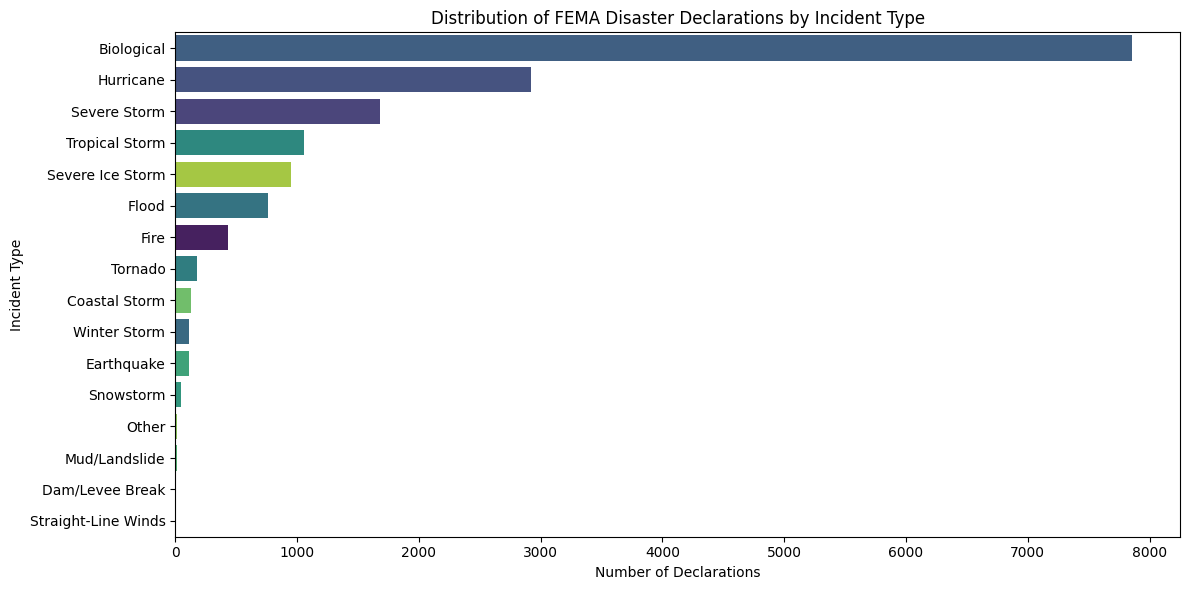

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=df_fema, y='incidentType', order=df_fema['incidentType'].value_counts().index, palette='viridis', hue='incidentType', legend=False)
plt.title('Distribution of FEMA Disaster Declarations by Incident Type')
plt.xlabel('Number of Declarations')
plt.ylabel('Incident Type')
plt.tight_layout()
plt.show()


To visualize the disaster trends over time, I will create a time series plot showing the number of declarations per year. First, I need to extract the year from the declarationDate column, then count the declarations per year, and finally plot the results.



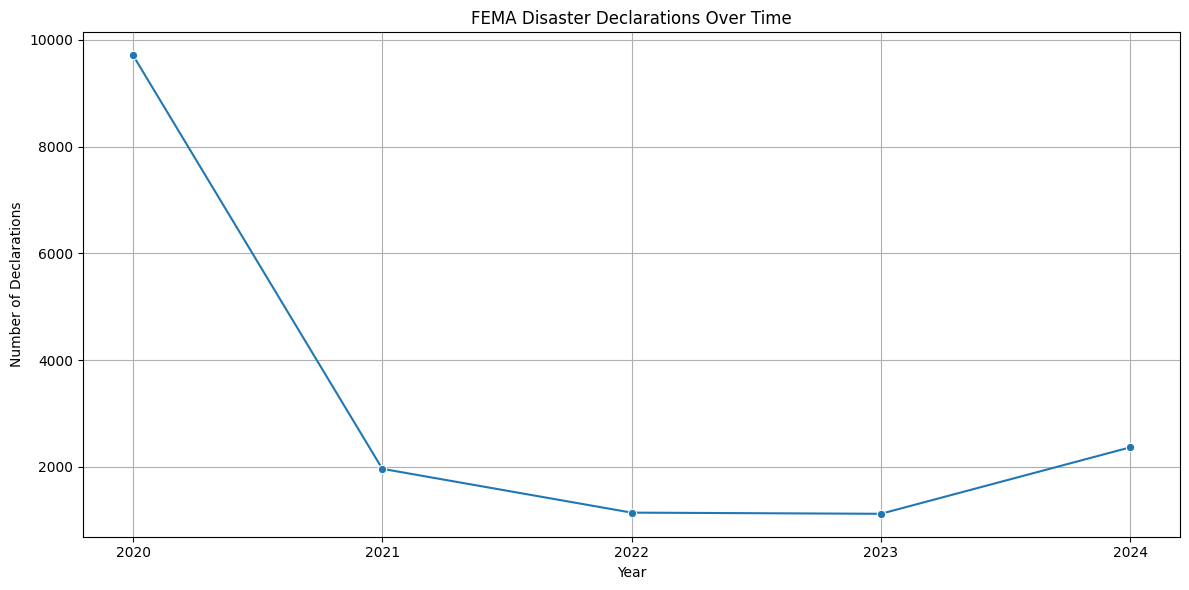

In [24]:
df_fema['year'] = df_fema['declarationDate'].dt.year
disasters_per_year = df_fema['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=disasters_per_year.index, y=disasters_per_year.values, marker='o')
plt.title('FEMA Disaster Declarations Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Declarations')
plt.xticks(disasters_per_year.index)
plt.grid(True)
plt.tight_layout()
plt.show()

## Analyze Census Data

Examine descriptive statistics for the Census DataFrame (df_census), focusing on population, income, poverty rates, and unemployment rates. Address the identified missing value sentinel in median household income. Visualize distributions of these key demographic variables.


first, we will replace the sentinel value -666666666 with NaN in the 'B19013_001E' column to correctly handle missing median household income data, as identified during the initial data exploration. This requires importing the `numpy` library.



In [25]:
import numpy as np

df_census['B19013_001E'] = df_census['B19013_001E'].replace(-666666666, np.nan)
print("Sentinel value -666666666 replaced with NaN in B19013_001E.")

Sentinel value -666666666 replaced with NaN in B19013_001E.



Next, we will rename the Census variable columns to more readable names as defined in the variables dictionary to improve readability and interpretability of the DataFrame.



In [44]:
df_census = df_census.rename(columns=variables)
print("renamed to readable names.")

renamed to readable names.



To understand the central tendency, dispersion, and shape of the distributions for key demographic variables, we will display descriptive statistics for `total_population`, `median_household_income`, `poverty_count`, `unemployment_count`, `labor_force_count`, `poverty_rate`, and `unemployment_rate` columns.



In [45]:
print("\nDescriptive statistics for key Census variables:")
print(df_census[['total_population', 'median_household_income', 'poverty_count', 'unemployment_count', 'labor_force_count', 'poverty_rate', 'unemployment_rate']].describe())


Descriptive statistics for key Census variables:
       total_population  median_household_income  poverty_count  \
count      3.222000e+03              3221.000000   3.222000e+03   
mean       1.037771e+05             62326.868053   1.300122e+04   
std        3.299494e+05             17770.571725   4.326437e+04   
min        5.000000e+01             14525.000000   3.000000e+00   
25%        1.103975e+04             51823.000000   1.526250e+03   
50%        2.591000e+04             60461.000000   3.799500e+03   
75%        6.737050e+04             70379.000000   9.767750e+03   
max        9.936690e+06            170463.000000   1.343978e+06   

       unemployment_count  labor_force_count  poverty_rate  unemployment_rate  
count         3222.000000       3.222000e+03   3222.000000        3222.000000  
mean          2827.343265       5.248424e+04     14.569523           5.156944  
std          10828.330102       1.734747e+05      7.497508           2.934424  
min              0.000000 


To visualize the distributions of key demographic variables, we will create a figure with subplots and plot histograms for `total_population`, `median_household_income`, `poverty_rate`, and `unemployment_rate`, ensuring each plot has appropriate titles and axis labels.



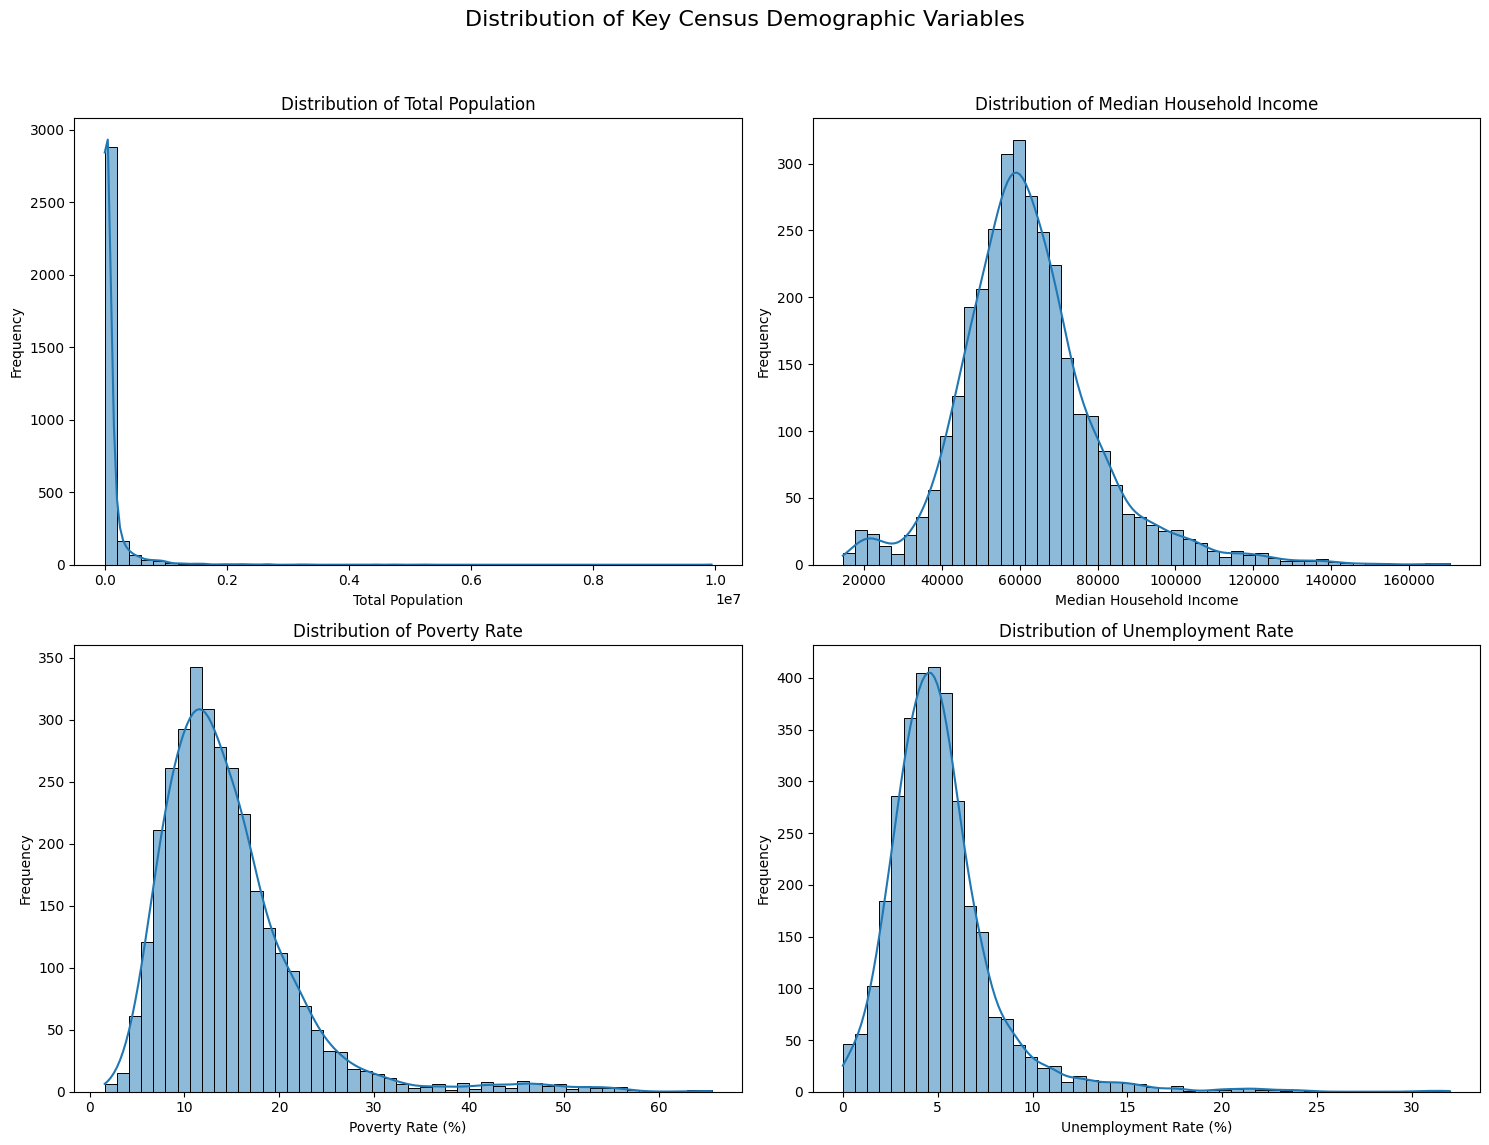

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribution of Key Census Demographic Variables', fontsize=16)

sns.histplot(df_census['total_population'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Total Population')
axes[0, 0].set_xlabel('Total Population')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df_census['median_household_income'].dropna(), bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Median Household Income')
axes[0, 1].set_xlabel('Median Household Income')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(df_census['poverty_rate'], bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Poverty Rate')
axes[1, 0].set_xlabel('Poverty Rate (%)')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(df_census['unemployment_rate'], bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Unemployment Rate')
axes[1, 1].set_xlabel('Unemployment Rate (%)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Interpretation of the chart:

These distributions show significant socioeconomic differences across counties. Variations in population size, income levels, poverty, and unemployment suggest that communities have different levels of economic resilience, which may influence how severely disasters impact them and how much federal disaster assistance they require.

## Analyze HUD Data

lets review descriptive statistics for the HUD DataFrame, particularly the Fair Market Rent values. Investigate the FIPS duplication issue and prepare a strategy for handling it, such as population-weighted averaging, before merging.


In [49]:
df_hud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4764 entries, 0 to 4763
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   stusps              4764 non-null   object
 1   state               4764 non-null   int64 
 2   hud_area_code       4764 non-null   object
 3   countyname          4764 non-null   object
 4   county_town_name    1604 non-null   object
 5   metro               4764 non-null   int64 
 6   hud_area_name       4764 non-null   object
 7   fips                4764 non-null   int64 
 8   pop2023             4764 non-null   int64 
 9   fmr_0               4764 non-null   int64 
 10  fmr_1               4764 non-null   int64 
 11  fmr_2               4764 non-null   int64 
 12  fmr_3               4764 non-null   int64 
 13  fmr_4               4764 non-null   int64 
 14  county_fips         4764 non-null   object
 15  county_fips_5digit  4764 non-null   object
dtypes: int64(9), object(7)
m

In [48]:
df_hud.isnull().sum()

,0
stusps,0
state,0
hud_area_code,0
countyname,0
county_town_name,3160
metro,0
hud_area_name,0
fips,0
pop2023,0
fmr_0,0



To address the FIPS duplication issue and prepare the HUD data for merging, we will first convert the 'fips' column to a 5-digit zero-padded string as county_fips_5digit.

Then, we will group the DataFrame by this new FIPS column and calculate the population-weighted average for all FMR-related columns (fmr_0 to fmr_4), using pop2023 as weights. Finally,  we will store the results in df_hud_cleaned, reset its index, print its shape, and display descriptive statistics for the FMR columns.



In [51]:
def weighted_average(df, value_col, weight_col):
    """Calculates the weighted average of a column."""
    # Handle cases where pop2023 might be 0 or NaN, which would lead to division by zero or incorrect weights
    # Only include records where weight is not NaN and positive
    valid_data = df[[value_col, weight_col]].dropna()
    valid_data = valid_data[valid_data[weight_col] > 0]

    if valid_data.empty:
        return np.nan

    value = valid_data[value_col]
    weight = valid_data[weight_col]
    return (value * weight).sum() / weight.sum()

# 1. Convert the 'fips' column to a 5-digit zero-padded string
df_hud['county_fips_5digit'] = df_hud['fips'].apply(lambda x: str(x).zfill(10)[:5])

# Columns for which to calculate weighted average
fmr_cols = ['fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4']

# Group by 5-digit FIPS and calculate population-weighted average for FMR columns
df_hud_cleaned = df_hud.groupby('county_fips_5digit').apply(lambda x: pd.Series({
    col: weighted_average(x, col, 'pop2023') for col in fmr_cols
}))

# 4. Reset the index of df_hud_cleaned
df_hud_cleaned = df_hud_cleaned.reset_index()

# 5. Print the shape of the cleaned HUD DataFrame
print(f"Shape: {df_hud_cleaned.shape}")
print(f"No.of unique FIPS codes: {df_hud_cleaned['county_fips_5digit'].nunique()}")

# 6. Display descriptive statistics for the FMR columns in df_hud_cleaned
print("\nDescriptive statistics:")
print(df_hud_cleaned[fmr_cols].describe())

Shape: (3229, 6)
No.of unique FIPS codes: 3229

Descriptive statistics:
             fmr_0        fmr_1        fmr_2        fmr_3        fmr_4
count  3229.000000  3229.000000  3229.000000  3229.000000  3229.000000
mean    883.451782   948.592262  1161.876197  1507.813732  1735.219512
std     308.964206   332.801388   379.122084   489.255840   579.993881
min     407.000000   410.000000   475.000000   621.000000   639.000000
25%     685.000000   742.000000   937.000000  1209.000000  1359.000000
50%     774.000000   830.000000  1018.000000  1344.000000  1552.000000
75%     983.000000  1057.000000  1273.000000  1669.000000  1934.000000
max    3179.000000  3298.000000  4214.000000  5377.000000  5659.000000


/tmp/ipython-input-1311649982.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_hud_cleaned = df_hud.groupby('county_fips_5digit').apply(lambda x: pd.Series({



To visually inspect the distributions of the cleaned Fair Market Rent (FMR) values, let us create histograms for each FMR column (fmr_0 to `fmr_4) from the df_hud_cleaned DataFrame. This will allow for an understanding of their spread and central tendency.



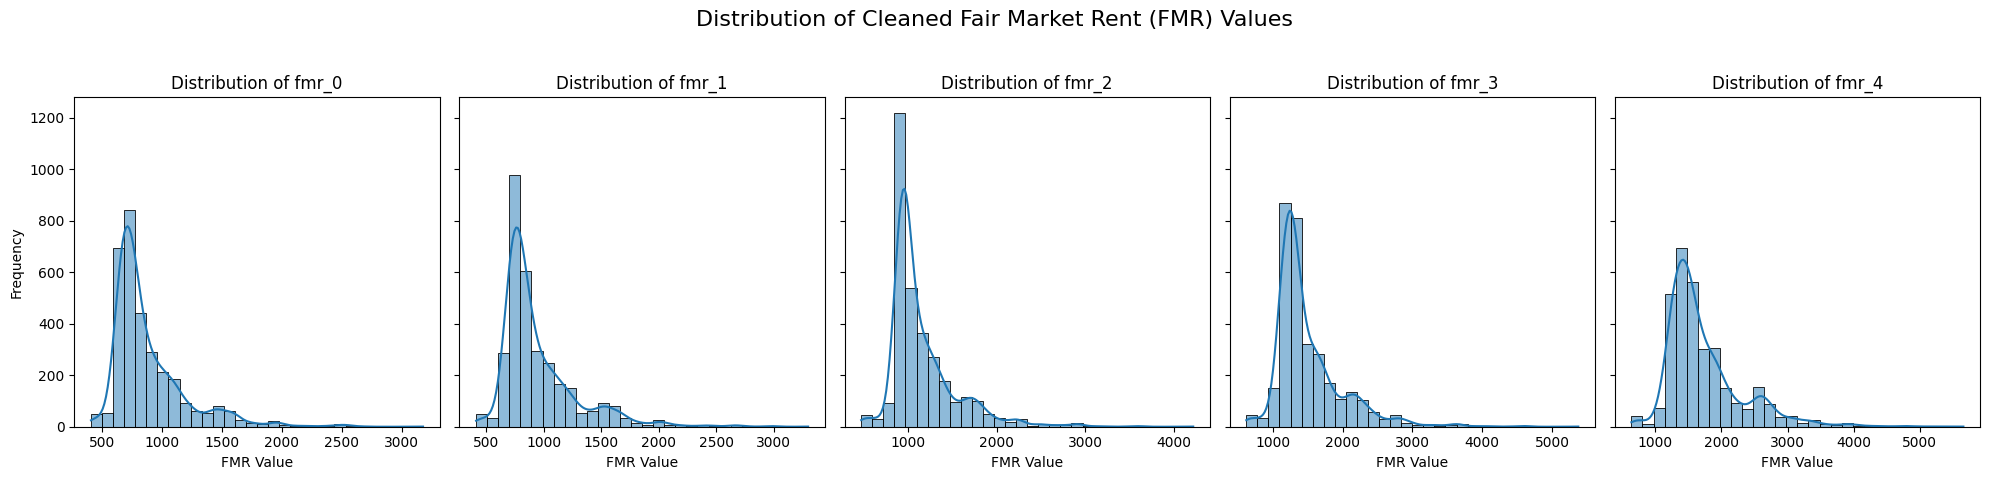

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fmr_cols = ['fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4']

fig, axes = plt.subplots(nrows=1, ncols=len(fmr_cols), figsize=(20, 5), sharey=True)
fig.suptitle('Distribution of Cleaned Fair Market Rent (FMR) Values', fontsize=16)

for i, col in enumerate(fmr_cols):
    sns.histplot(df_hud_cleaned[col].dropna(), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('FMR Value')
    axes[i].set_ylabel('Frequency' if i == 0 else '')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Interpretation: Higher Fair Market Rent values indicate elevated housing market costs and potential economic exposure, suggesting that disaster recovery expenses may be higher in these counties, which could influence the level of FEMA assistance allocations.

## Prepare Data for Merging

Standardize FIPS codes across all three datasets to a consistent 5-digit format.



To standardize FEMA FIPS codes, we will combine the fipsStateCode and fipsCountyCode columns in df_fema into a new 5-digit zero-padded string column named 'fips', ensuring consistency for merging.



In [34]:
df_fema['fips'] = df_fema['fipsStateCode'].astype(str).str.zfill(2) + df_fema['fipsCountyCode'].astype(str).str.zfill(3)
print("First 5 rows of df_fema with new 'fips' column:")
print(df_fema[['fipsStateCode', 'fipsCountyCode', 'fips']].head())
print(f"Data type of df_fema['fips']: {df_fema['fips'].dtype}")

First 5 rows of df_fema with new 'fips' column:
   fipsStateCode fipsCountyCode   fips
0             41            067  41067
1             41            031  41031
2             41            017  41017
9             41            001  41001
10            41            045  41045
Data type of df_fema['fips']: object


## Merge Datasets

The processed FEMA, Census, and HUD datasets are combined into a single comprehensive dataset using standardized 5-digit FIPS codes to ensure consistent county-level matching across all sources.

To prepare the FEMA dataset for merging with county-level demographic and housing data, the dataset is aggregated by the fips column.

For each county, the total number of disaster declarations is calculated, and the program declaration indicators are summed to determine how many times each FEMA assistance program was activated. The aggregated results are stored in df_fema_agg_by_fips.


In [36]:
program_cols = ['ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared']

df_fema_agg_by_fips = df_fema.groupby('fips').agg(
    declaration_count=('fips', 'size'),
    ihProgramDeclared_sum=('ihProgramDeclared', 'sum'),
    iaProgramDeclared_sum=('iaProgramDeclared', 'sum'),
    paProgramDeclared_sum=('paProgramDeclared', 'sum'),
    hmProgramDeclared_sum=('hmProgramDeclared', 'sum')
).reset_index()

print("First 5 rows of df_fema_agg_by_fips:")
print(df_fema_agg_by_fips.head())
print(f"Shape of df_fema_agg_by_fips: {df_fema_agg_by_fips.shape}")

First 5 rows of df_fema_agg_by_fips:
    fips  declaration_count  ihProgramDeclared_sum  iaProgramDeclared_sum  \
0  01000                  7                      3                      0   
1  01001                  6                      2                      0   
2  01003                  5                      2                      0   
3  01005                  7                      1                      0   
4  01007                  5                      2                      0   

   paProgramDeclared_sum  hmProgramDeclared_sum  
0                      7                      4  
1                      6                      3  
2                      5                      2  
3                      7                      4  
4                      5                      2  
Shape of df_fema_agg_by_fips: (3277, 6)


To create a combined county-level dataset, the df_census and df_hud_cleaned DataFrames are merged using an outer join based on their FIPS codes.

The county_fips_5digit column in df_hud_cleaned is first renamed to fips to ensure consistency with df_census and allow accurate matching during the merge. The resulting merged dataset is stored in df_merged_census_hud.


In [37]:
df_hud_cleaned = df_hud_cleaned.rename(columns={'county_fips_5digit': 'fips'})
df_merged_census_hud = pd.merge(df_census, df_hud_cleaned, on='fips', how='outer')

print("First 5 rows of df_merged_census_hud:")
print(df_merged_census_hud.head())
print(f"Shape of df_merged_census_hud: {df_merged_census_hud.shape}")

First 5 rows of df_merged_census_hud:
                      NAME  total_population  median_household_income  \
0  Autauga County, Alabama           58761.0                  68315.0   
1  Baldwin County, Alabama          233420.0                  71039.0   
2  Barbour County, Alabama           24877.0                  39712.0   
3     Bibb County, Alabama           22251.0                  50669.0   
4   Blount County, Alabama           59077.0                  57440.0   

   poverty_count  unemployment_count  labor_force_count state county  \
0         6630.0               752.0            27163.0    01    001   
1        23445.0              3825.0           111079.0    01    003   
2         5280.0               516.0             8968.0    01    005   
3         4297.0               786.0             9028.0    01    007   
4         8277.0              1578.0            26434.0    01    009   

  state_fips county_fips   fips  poverty_rate  unemployment_rate   fmr_0  \
0         01  

To complete the merging process and create the final comprehensive dataset, an outer join is performed between df_merged_census_hud and df_fema_agg_by_fips using the fips column as the common key. This step integrates the FEMA disaster information with the Census demographic data and HUD housing data, resulting in a unified dataset stored as df_final_merged.

In [38]:
df_final_merged = pd.merge(df_merged_census_hud, df_fema_agg_by_fips, on='fips', how='outer')

print("First 5 rows of df_final_merged:")
print(df_final_merged.head())
print(f"Shape of df_final_merged: {df_final_merged.shape}")

First 5 rows of df_final_merged:
                      NAME  total_population  median_household_income  \
0                      NaN               NaN                      NaN   
1  Autauga County, Alabama           58761.0                  68315.0   
2  Baldwin County, Alabama          233420.0                  71039.0   
3  Barbour County, Alabama           24877.0                  39712.0   
4     Bibb County, Alabama           22251.0                  50669.0   

   poverty_count  unemployment_count  labor_force_count state county  \
0            NaN                 NaN                NaN   NaN    NaN   
1         6630.0               752.0            27163.0    01    001   
2        23445.0              3825.0           111079.0    01    003   
3         5280.0               516.0             8968.0    01    005   
4         4297.0               786.0             9028.0    01    007   

  state_fips county_fips  ...   fmr_0   fmr_1   fmr_2   fmr_3   fmr_4  \
0        NaN         N

To simply put what we did:

First, the FEMA dataset was prepared for merging. Since FEMA records multiple disaster events for the same county, the data was aggregated so that each county appeared only once. For every county, the total number of disaster declarations was counted, and the number of times each FEMA assistance program was activated was calculated. This created a county-level summary of disaster impact.

Next, the Census and HUD datasets were merged using their shared FIPS codes. The Census dataset provided demographic and socioeconomic information such as population, income, poverty, and unemployment, while the HUD dataset contributed housing cost information through Fair Market Rent values. An outer join was used to retain all counties even if information was missing from one dataset.

Finally, the aggregated FEMA dataset was merged with the combined Census and HUD dataset using the same FIPS identifier. This step integrated disaster outcomes with demographic and housing characteristics, resulting in a single comprehensive dataset where each row represents one county and includes socioeconomic conditions, housing market information, and disaster assistance measures.

Summary: Data Analysis Key Findings

1. FEMA Disaster Data

- The FEMA dataset contains 16,298 disaster declarations between 2020 and 2024.
- Most declarations involved Public Assistance (PA) and Hazard Mitigation (HM) programs, followed by Individual Housing Assistance (IH).
- No Individual Assistance (IA) declarations were recorded during this period.
- Biological incidents were the most common disaster type, followed by hurricanes and severe storms.
- Visualizations showed how disasters varied across time and incident types.

2. Census Socioeconomic Data

- Missing income values marked as -666666666 were replaced with NaN to allow accurate analysis.

- Columns were renamed to make them easier to understand.

- Median household income averages about $62,327, while poverty rates vary widely across counties.

- Histograms showed differences in population size, income levels, poverty rates, and unemployment across counties.

- HUD Fair Market Rent (FMR) Data

- Duplicate county entries were cleaned using population-weighted averages, creating one row per county.

- Rent values vary significantly across counties.

- Efficiency unit rents average about $883, while four-bedroom rents average about $1,735.

- Histograms helped visualize housing cost differences.

3. Data Integration

- FIPS codes were standardized across FEMA, Census, and HUD datasets.

- FEMA data was aggregated so each county had one summary row showing disaster counts and assistance programs.

- All datasets were merged into a final dataset called df_final_merged, containing 3,292 counties and 23 columns, ready for analysis.

4. Insights and Next Steps

- The merged dataset allows comparison of disaster frequency with income, poverty, unemployment, and housing costs.

- The next step is to analyze correlations between disasters and socioeconomic factors to better understand community vulnerability.